In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load cleaned transactions
raw_path = Path("../data/raw/online_retail_ii.xlsx")
tx = pd.read_excel(raw_path)

tx = tx.rename(columns={
    "Customer ID": "CustomerID",
    "Price": "UnitPrice",
}).copy()

tx["InvoiceDate"] = pd.to_datetime(tx["InvoiceDate"], errors="coerce")
tx["Invoice"] = tx["Invoice"].astype(str)

tx = tx.dropna(subset=["CustomerID", "InvoiceDate", "Quantity", "UnitPrice"])
tx = tx.loc[~tx["Invoice"].str.startswith("C")]
tx = tx.loc[tx["Quantity"] > 0]
tx = tx.loc[tx["UnitPrice"] > 0]

tx["LineRevenue"] = tx["Quantity"] * tx["UnitPrice"]
tx["StockCode"] = tx["StockCode"].astype(str)

In [2]:
sku_code = "22189"

sku_tx = tx.loc[tx["StockCode"] == sku_code].copy()

weekly = (
    sku_tx
    .groupby(pd.Grouper(key="InvoiceDate", freq="W-MON"))
    .agg(
        units=("Quantity", "sum"),
        avg_price=("UnitPrice", "mean"),
    )
    .reset_index()
)

weekly = weekly.loc[
    (weekly["units"] > 0) &
    (weekly["avg_price"] > 0)
].copy()

weekly.head(), weekly.shape

(  InvoiceDate  units  avg_price
 0  2009-12-07    312   3.870000
 1  2009-12-14    219   3.876957
 2  2009-12-21    214   3.925652
 4  2010-01-04      1   3.950000
 5  2010-01-11    104   3.899091,
 (45, 3))

In [3]:
weekly["log_units"] = np.log(weekly["units"])
weekly["log_price"] = np.log(weekly["avg_price"])

X = sm.add_constant(weekly["log_price"])
y = weekly["log_units"]

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_units   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     39.32
Date:                Tue, 06 Jan 2026   Prob (F-statistic):           1.48e-07
Time:                        15:46:30   Log-Likelihood:                -54.694
No. Observations:                  45   AIC:                             113.4
Df Residuals:                      43   BIC:                             117.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         45.3532      6.467      7.013      0.000      32.312      58.395
log_price    -29.9099      4.770     -6.270      0.000     -39.530     -20.290
==============================================================================
Omnibus:                       56.274   Durbin-Watson:                   2.145
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              440.078
Skew:                          -2.950   Prob(JB):                     2.74e-96
Kurtosis:                      17.138   Cond. No.                         109.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [4]:
X = sm.add_constant(weekly["avg_price"])
y = weekly["log_units"]

model_semi = sm.OLS(y, X).fit()
model_semi.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_units   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.471
Method:                 Least Squares   F-statistic:                     40.16
Date:                Tue, 06 Jan 2026   Prob (F-statistic):           1.18e-07
Time:                        15:49:09   Log-Likelihood:                -54.466
No. Observations:                  45   AIC:                             112.9
Df Residuals:                      43   BIC:                             116.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.7805      4.889      7.319      0.000      25.922      45.639
avg_price     -7.9820      1.260     -6.337      0.000     -10.522      -5.442
==============================================================================
Omnibus:                       56.671   Durbin-Watson:                   2.144
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              447.055
Skew:                          -2.977   Prob(JB):                     8.38e-98
Kurtosis:                      17.247   Cond. No.                         163.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [5]:
# Baseline price definition
baseline_price = weekly["avg_price"].median()
baseline_price

3.9069230769230767

In [6]:
weekly = weekly.assign(
    is_discounted=lambda d: d["avg_price"] < baseline_price,
    revenue=lambda d: d["units"] * d["avg_price"]
)

weekly["is_discounted"].value_counts()

False    23
True     22
Name: is_discounted, dtype: int64

In [7]:
promo_summary = (
    weekly.groupby("is_discounted")
          .agg(
              weeks=("units", "count"),
              avg_units=("units", "mean"),
              avg_price=("avg_price", "mean"),
              avg_revenue=("revenue", "mean"),
              total_revenue=("revenue", "sum"),
          )
)

promo_summary

,weeks,avg_units,avg_price,avg_revenue,total_revenue
is_discounted,,,,,
False,23,87.391304,3.938345,343.749335,7906.234695
True,22,359.454545,3.818502,1335.311670,29376.856733


In [8]:
promo_summary.assign(
    revenue_per_week=lambda d: d["total_revenue"] / d["weeks"]
)

,weeks,avg_units,avg_price,avg_revenue,total_revenue,revenue_per_week
is_discounted,,,,,,
False,23,87.391304,3.938345,343.749335,7906.234695,343.749335
True,22,359.454545,3.818502,1335.311670,29376.856733,1335.311670


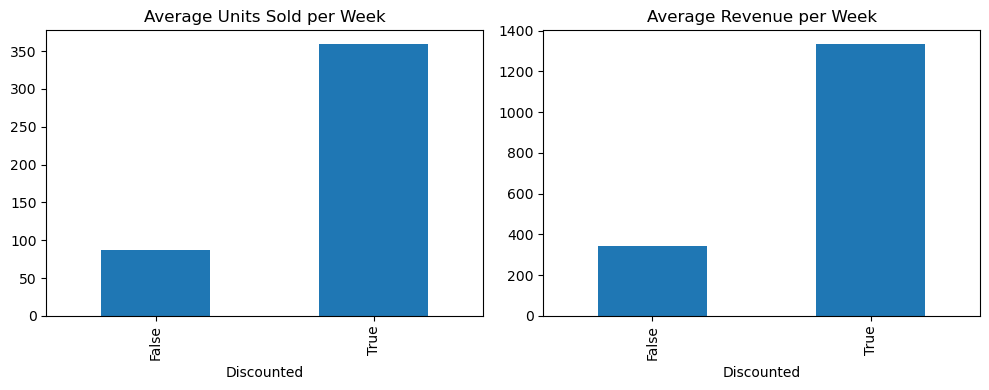

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

promo_summary["avg_units"].plot(
    kind="bar",
    ax=axes[0],
    title="Average Units Sold per Week",
)
axes[0].set_xlabel("Discounted")

promo_summary["avg_revenue"].plot(
    kind="bar",
    ax=axes[1],
    title="Average Revenue per Week",
)
axes[1].set_xlabel("Discounted")

plt.tight_layout()
plt.show()

In [13]:
from scipy import stats

disc = weekly.loc[weekly["is_discounted"], "revenue"]
full = weekly.loc[~weekly["is_discounted"], "revenue"]

stats.ttest_ind(disc, full, equal_var=False)

Ttest_indResult(statistic=2.993178437555992, pvalue=0.006796127105821711)

In [14]:
import pandas as pd
from pathlib import Path

pricing_flags = pd.DataFrame([
    {
        "StockCode": "22189",
        "price_elasticity_class": "High",
        "evidence": "Discounted weeks ~4x higher revenue/week; strong volume response to small price drops"
    }
])

out_path = Path("../data/processed/sku_pricing_flags.csv")
pricing_flags.to_csv(out_path, index=False)
out_path

WindowsPath('../data/processed/sku_pricing_flags.csv')

In [16]:
# Recreate pricing_candidates in this notebook
sku_price_stats = (
    tx.groupby("StockCode")
      .agg(
          n_transactions=("Invoice", "count"),
          n_unique_prices=("UnitPrice", "nunique"),
          total_revenue=("LineRevenue", "sum"),
      )
      .reset_index()
)

pricing_candidates = sku_price_stats.loc[
    (sku_price_stats["n_unique_prices"] >= 4) &
    (sku_price_stats["n_transactions"] >= 50)
].copy()

pricing_candidates.shape

(132, 4)

In [33]:
import statsmodels.api as sm

results = []

for sku_code in pricing_candidates["StockCode"]:

    sku_tx = tx.loc[tx["StockCode"] == sku_code].copy()

    weekly = (
        sku_tx
        .groupby(pd.Grouper(key="InvoiceDate", freq="W-MON"))
        .agg(
            units=("Quantity", "sum"),
            avg_price=("UnitPrice", "mean"),
        )
        .reset_index()
    )

    weekly = weekly.loc[(weekly["units"] > 0) & (weekly["avg_price"] > 0)].copy()

    # Minimum data check
    if weekly.shape[0] < 20 or weekly["avg_price"].nunique() < 3:
        results.append({
            "StockCode": sku_code,
            "price_elasticity_class": "Unknown",
            "semi_elasticity": np.nan,
            "r2": np.nan,
            "weeks": int(weekly.shape[0]),
            "n_unique_prices": int(weekly["avg_price"].nunique()),
            "evidence": "Insufficient price variation or history",
        })
        continue

    weekly["log_units"] = np.log(weekly["units"])
    X = sm.add_constant(weekly["avg_price"])
    y = weekly["log_units"]

    try:
        model = sm.OLS(y, X).fit()
        beta = float(model.params["avg_price"])
        r2 = float(model.rsquared)
    except Exception as e:
        results.append({
            "StockCode": sku_code,
            "price_elasticity_class": "Unknown",
            "semi_elasticity": np.nan,
            "r2": np.nan,
            "weeks": int(weekly.shape[0]),
            "n_unique_prices": int(weekly["avg_price"].nunique()),
            "evidence": f"Model failed: {type(e).__name__}",
        })
        continue

    # Classification (keep High strict; allow Moderate with weaker R²)
    if beta <= -1.2 and r2 >= 0.35:
        klass = "High"
    elif beta <= -0.5 and r2 >= 0.10:
        klass = "Moderate"
    elif beta < 0:
        klass = "Low"
    else:
        klass = "Low"

    results.append({
        "StockCode": sku_code,
        "price_elasticity_class": klass,
        "semi_elasticity": round(beta, 3),
        "r2": round(r2, 3),
        "weeks": int(weekly.shape[0]),
        "n_unique_prices": int(weekly["avg_price"].nunique()),
        "evidence": f"beta={beta:.2f}, R²={r2:.2f}",
    })

pricing_flags = pd.DataFrame(results)
pricing_flags.head()

,StockCode,price_elasticity_class,semi_elasticity,r2,weeks,n_unique_prices,evidence
0,15036,Low,3.410,0.011,47,20,"beta=3.41, R²=0.01"
1,15056BL,High,-4.256,0.375,53,20,"beta=-4.26, R²=0.37"
2,15056N,High,-3.490,0.410,52,25,"beta=-3.49, R²=0.41"
3,15056P,High,-4.356,0.497,49,10,"beta=-4.36, R²=0.50"
4,17003,Moderate,-52.791,0.158,46,14,"beta=-52.79, R²=0.16"


In [31]:
pricing_flags[["semi_elasticity", "r2"]].describe()

,semi_elasticity,r2
count,127.000000,127.000000
mean,-5.974079,0.250496
std,10.229325,0.177464
min,-52.791000,0.000000
25%,-7.862000,0.098000
50%,-3.266000,0.235000
75%,-0.896500,0.380000
max,27.379000,0.664000


In [34]:
pricing_flags["price_elasticity_class"].value_counts()

Moderate    53
Low         40
High        34
Unknown      5
Name: price_elasticity_class, dtype: int64

In [35]:
from pathlib import Path

out_path = Path("../data/processed/sku_pricing_flags.csv")
pricing_flags.to_csv(out_path, index=False)
out_path

WindowsPath('../data/processed/sku_pricing_flags.csv')

In [36]:
pricing_flags.loc[pricing_flags["price_elasticity_class"].isin(["High", "Moderate"])].sort_values("semi_elasticity").head(15)

,StockCode,price_elasticity_class,semi_elasticity,r2,weeks,n_unique_prices,evidence
4,17003,Moderate,-52.791,0.158,46,14,"beta=-52.79, R²=0.16"
79,22469,Moderate,-48.390,0.179,32,22,"beta=-48.39, R²=0.18"
39,21977,Moderate,-35.241,0.316,52,28,"beta=-35.24, R²=0.32"
120,84347,High,-27.769,0.481,26,12,"beta=-27.77, R²=0.48"
75,22432,High,-24.749,0.394,40,9,"beta=-24.75, R²=0.39"
13,21166,Moderate,-19.950,0.258,46,23,"beta=-19.95, R²=0.26"
71,22385,High,-18.532,0.384,46,23,"beta=-18.53, R²=0.38"
69,22379,High,-16.661,0.385,47,20,"beta=-16.66, R²=0.38"
33,21903,Moderate,-15.579,0.208,50,8,"beta=-15.58, R²=0.21"
30,21875,Moderate,-15.570,0.254,51,9,"beta=-15.57, R²=0.25"
